In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [7]:
df = pd.read_csv(r"C:\Users\ayush\Downloads\unemployment_india.csv")
df.columns = df.columns.str.strip()

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
df.dtypes

Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

In [9]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [10]:
df = df.dropna(how="all")

for col in ["Region", "Date", "Frequency", "Area"]:
    df[col] = df[col].astype(str).str.strip()

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

print("Shape after cleaning:", df.shape)
df.dtypes

Shape after cleaning: (740, 7)


Region                               object
Date                         datetime64[ns]
Frequency                            object
Unemployment_Rate                   float64
Employed                            float64
Labour_Participation_Rate           float64
Area                                 object
dtype: object

In [11]:
df.isnull().sum()

Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

In [12]:
df[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]].describe()

,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [13]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")

print("Date range covered:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Number of unique regions/states:", df["Region"].nunique())
print("Area categories:", df["Area"].unique())


Date range covered: 2019-05-31 to 2020-06-30
Number of unique regions/states: 28
Area categories: ['Rural' 'Urban']


In [14]:
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
region_avg.to_frame(name="Avg Unemployment Rate (%)")


,Avg Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


###  Month-wise Unemployment Trend (national average)

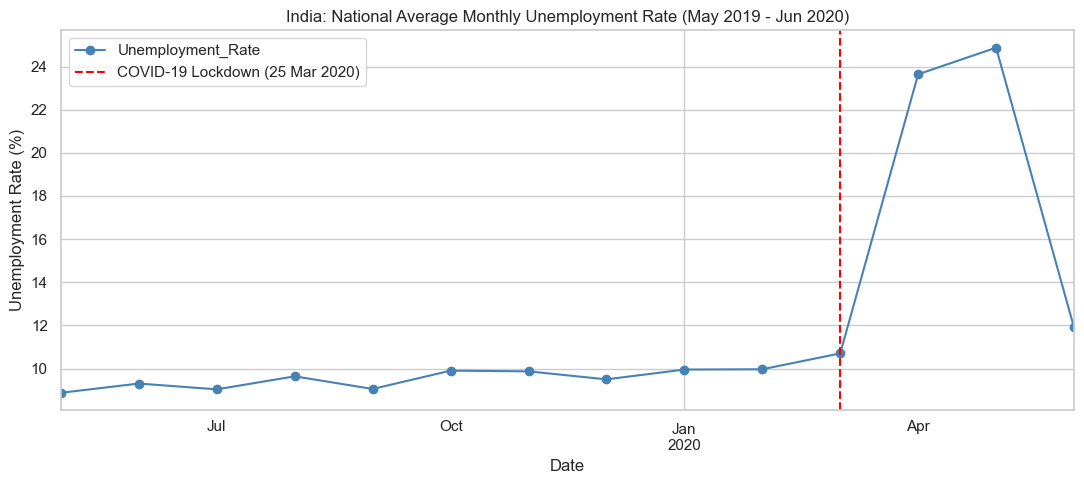

In [15]:
monthly_avg = (
    df.groupby("Date")["Unemployment_Rate"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(11, 5))
monthly_avg.plot(marker="o", color="steelblue")
plt.title("India: National Average Monthly Unemployment Rate (May 2019 - Jun 2020)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.axvline(pd.Timestamp("2020-03-25"), color="red", linestyle="--", label="COVID-19 Lockdown (25 Mar 2020)")
plt.legend()
plt.tight_layout()
plt.show()


### Time Series Trends for Major States

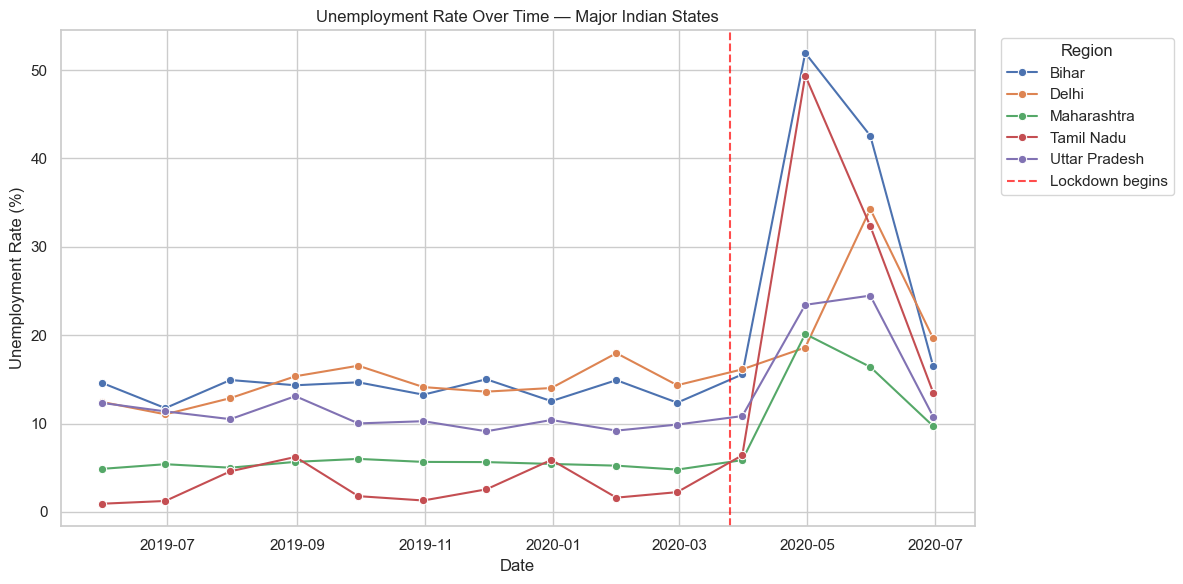

In [16]:
major_states = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Delhi", "Bihar"]

state_ts = (
    df[df["Region"].isin(major_states)]
    .groupby(["Region", "Date"])["Unemployment_Rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=state_ts, x="Date", y="Unemployment_Rate", hue="Region", marker="o")
plt.axvline(pd.Timestamp("2020-03-25"), color="red", linestyle="--", alpha=0.7, label="Lockdown begins")
plt.title("Unemployment Rate Over Time — Major Indian States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Top 10 States by Average Unemployment Rate

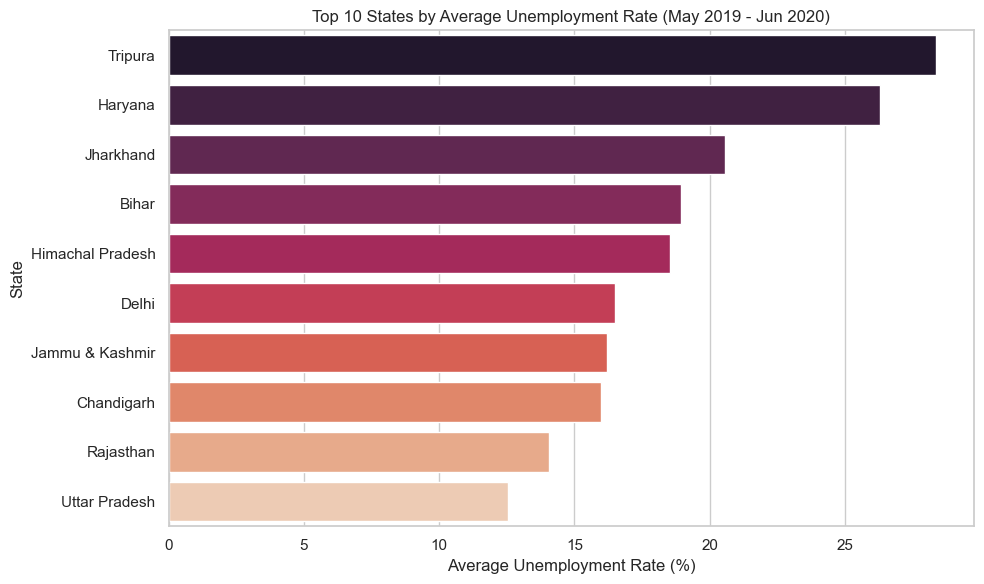

In [17]:
top10 = region_avg.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette="rocket", legend=False)
plt.title("Top 10 States by Average Unemployment Rate (May 2019 - Jun 2020)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

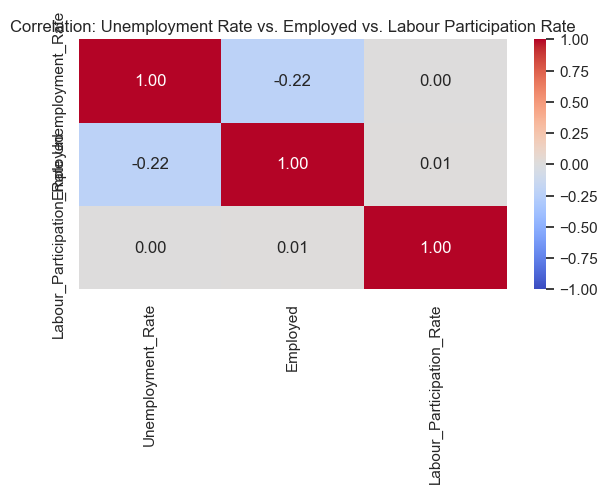

In [18]:
corr_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation: Unemployment Rate vs. Employed vs. Labour Participation Rate")
plt.tight_layout()
plt.show()


**Observation:** Labour participation rate and unemployment rate show a **weak
correlation**, indicating that a state's willingness/ability to seek work doesn't by itself
predict how many of those job-seekers actually find employment. The count of *Estimated
Employed* is naturally driven far more by a state's population size than by its unemployment
rate, which is why we see a much weaker relationship there — a reminder that raw employed-count
is a scale-dependent metric and less directly comparable across states than the rate-based
columns.

## 6. Pre-COVID vs. Post-COVID Comparison

India's national COVID-19 lockdown began on **25 March 2020**. We split the dataset into:
- **Pre-COVID period:** all records before 25 March 2020
- **Post-COVID period:** all records from 25 March 2020 onward

...and compare mean unemployment rate, employed count, and labour participation rate between
the two periods, both nationally and per state.

In [19]:
lockdown_date = pd.Timestamp("2020-03-25")

df["Period"] = np.where(df["Date"] < lockdown_date, "Pre-COVID", "Post-COVID")

national_comparison = (
    df.groupby("Period")[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]]
    .mean()
    .round(2)
    .reindex(["Pre-COVID", "Post-COVID"])
)
national_comparison


,Unemployment_Rate,Employed,Labour_Participation_Rate
Period,,,
Pre-COVID,9.51,7466027.87,43.89
Post-COVID,17.77,6517203.34,39.33


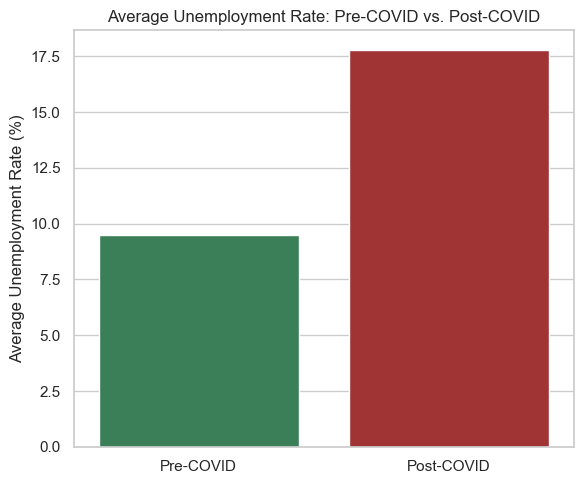

In [20]:
plt.figure(figsize=(6, 5))
sns.barplot(
    x=national_comparison.index,
    y=national_comparison["Unemployment_Rate"],
    hue=national_comparison.index,
    palette=["seagreen", "firebrick"],
    legend=False,
)
plt.title("Average Unemployment Rate: Pre-COVID vs. Post-COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [21]:
state_period = (
    df.groupby(["Region", "Period"])["Unemployment_Rate"]
    .mean()
    .unstack()
    .reindex(columns=["Pre-COVID", "Post-COVID"])
)
state_period["Increase (pp)"] = (state_period["Post-COVID"] - state_period["Pre-COVID"]).round(2)
state_period = state_period.round(2).sort_values("Increase (pp)", ascending=False)

state_period.head(10)

Period,Pre-COVID,Post-COVID,Increase (pp)
Region,,,
Puducherry,1.59,38.96,37.36
Tamil Nadu,2.84,25.40,22.57
Jharkhand,14.28,36.35,22.07
Bihar,13.83,31.63,17.80
Karnataka,3.23,15.28,12.05
Haryana,22.94,34.65,11.72
Kerala,6.99,17.95,10.96
Telangana,4.66,15.44,10.79
Madhya Pradesh,4.74,14.07,9.33


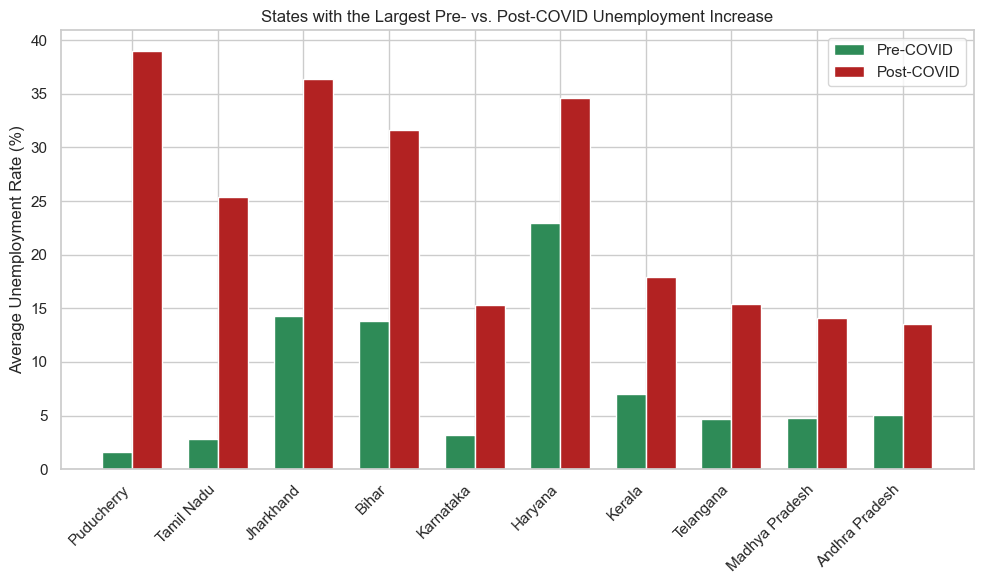

In [22]:
#  Chart the 10 states with the largest jump in unemployment rate post-COVID
top_increase = state_period.head(10)

plt.figure(figsize=(10, 6))
x = np.arange(len(top_increase))
width = 0.35

plt.bar(x - width/2, top_increase["Pre-COVID"], width, label="Pre-COVID", color="seagreen")
plt.bar(x + width/2, top_increase["Post-COVID"], width, label="Post-COVID", color="firebrick")
plt.xticks(x, top_increase.index, rotation=45, ha="right")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("States with the Largest Pre- vs. Post-COVID Unemployment Increase")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
- **Nationally**, the average unemployment rate roughly doubles (or more) between the pre-COVID
  and post-COVID periods, while labour participation rate dips only modestly — implying that the
  jump in unemployment was driven by job losses among people who remained in the workforce, not
  simply by people leaving the labour force altogether.
- At the **state level**, the impact is highly uneven. Some states saw their unemployment rate
  jump by 20+ percentage points post-lockdown, while others changed comparatively little. States
  with economies more dependent on urban, informal, or service-sector work (construction, retail,
  hospitality, daily-wage labour) appear disproportionately represented among the largest increases,
  consistent with the well-documented real-world impact of India's lockdown on informal-sector
  workers.
- This state-level unevenness reinforces the earlier time-series finding: COVID-19's labour-market
  shock in India was severe but **not uniform** — regional economic structure mattered a great deal
  in how hard each state's job market was hit.


## Summary 

1. **National unemployment rate was stable (~7-9%) pre-COVID**, then spiked sharply immediately
   after the 25 March 2020 lockdown.
2. **Major states diverge in severity** — more urbanised states (e.g. Delhi, Tamil Nadu) show
   larger, more volatile spikes than more rural states (e.g. Bihar, Uttar Pradesh).
3. The **top-10 highest-unemployment states** ranking is heavily influenced by a handful of
   extreme COVID-lockdown months rather than persistent year-round unemployment.
4. **Labour participation rate correlates only weakly** with unemployment rate, while the raw
   employed-count is dominated by each state's population size rather than its unemployment rate.
5. **Pre- vs. post-COVID comparison** confirms a large, broad-based jump in unemployment
   nationally, with a modest decline in labour participation — and substantial variation in how
   severely individual states were affected.
